# PolyChord widePlanck mock-MCMC: chain plots

Adapted from `Plot_MOR_only_Johnny_Chains.ipynb` for the 10-parameter
`mock_mcmc_cp_camb.ini` polychord run (5 cosmology + 5 HOD).

**PolyChord output is weighted** (see cosmosis docs): every posterior
estimate / histogram MUST use the `weight` column. ChainConsumer handles
this via `add_chain(..., weights=...)`.

**A/B test (2026-06-26):** two converged polychord runs on the same JK-cov DV,
differing only in the likelihood space:
- **linear** (`chain.txt`, job 55014977) — Gaussian on the raw observables.
- **log-space** (`polychord_logspace/chain.txt`, job 55040404) — Gaussian on
  ln(NC), ln(shear), cov propagated by the delta method (`likelihoods.log_space=T`).

Result: the two posteriors are **statistically identical** (all means agree
<0.05σ, σ within ~2%) and converged in the **same** wall time (~8h41m vs
8h45m). The log transform does not speed parameter-space convergence here, so
the inis are set back to `log_space = F`. This notebook overlays both to
document that.

The s8 emulator samples **`sigma8` directly** — no derived-σ₈ post-processing
(`chain_sigma8.txt`) is needed anymore.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from chainconsumer import ChainConsumer

plt.rcParams.update({'font.size': 16})
# usetex off by default on NERSC (no system latex on compute nodes); flip on if you have it.
plt.rc('text', usetex=False)

In [2]:
# Both converged polychord chains on the JK-cov DV (mock_dv_widePlanck_jkcov.npz:
# Poisson NC + Buzzard jackknife shear cov, cond~2.8e3, rebinned 20->15 radii).
# The s8 emulator samples sigma8 directly, so the column layout is:
#   h0, omega_m, omega_b, n_s, sigma8,
#   log10_mmin, log10_ratio, alpha, epsilon, sigma_lambda,
#   prior, like, post, weight
# NOTE: cosmosis writes a leading-tab header that drops the first (h0) name and
# 2 '#log_z=' comment lines on top, so a plain read_csv mis-parses. Load with
# explicit names + skiprows to be robust.
COLS = ['h0', 'omega_m', 'omega_b', 'n_s', 'sigma8',
        'log10_mmin', 'log10_ratio', 'alpha', 'epsilon', 'sigma_lambda',
        'prior', 'like', 'post', 'weight']

def load_chain(path):
    df = pd.read_csv(path, sep=r'\s+', comment='#', header=None,
                     names=COLS, skiprows=3)
    return df

chains = {
    'linear':    load_chain('/pscratch/sd/j/jesteves/cluster_lib/chains/mock_mcmc/chain.txt'),
    'log-space': load_chain('/pscratch/sd/j/jesteves/cluster_lib/chains/mock_mcmc/polychord_logspace/chain.txt'),
}
# Primary chain used for the single-chain plots / summary table.
chain = chains['linear']
print({k: v.shape for k, v in chains.items()})
chain.head()

{'linear': (12360, 14), 'log-space': (12721, 14)}


,h0,omega_m,omega_b,n_s,sigma8,log10_mmin,log10_ratio,alpha,epsilon,sigma_lambda,prior,like,post,weight
0,0.843896,0.368056,0.039879,1.043386,1.297791,10.595430,1.090916,0.619629,-0.425954,0.394066,4.308271,-963559.316957,-963555.008686,0.0
1,0.784574,0.252643,0.091713,1.090825,1.190211,11.349396,1.050269,1.087695,0.038392,0.480347,4.308271,-961398.348190,-961394.039919,0.0
2,0.538472,0.280908,0.052841,1.040853,1.245193,11.483235,1.073167,1.191552,0.575410,0.422339,4.308271,-939195.829831,-939191.521560,0.0
3,0.642623,0.594262,0.076537,0.895784,1.310094,12.463296,1.238437,0.667219,-0.825106,0.243812,4.308271,-905110.603826,-905106.295555,0.0
4,0.806102,0.830071,0.094885,0.941371,0.906303,12.402565,1.170817,0.599654,0.409521,0.205447,4.308271,-900849.803025,-900845.494755,0.0


In [3]:
# Report effective sample size for each run and reconstruct log10_M1.
for name, df in chains.items():
    ess = df['weight'].sum()**2 / (df['weight']**2).sum()
    print(f'{name:10s}: {len(df)} weighted samples; ESS ~ {ess:.0f}')
    # log10_M1 = log10_Mmin + log10_ratio (HOD M1/Mmin ratio convention).
    df['log10_m1'] = df['log10_mmin'] + df['log10_ratio']

linear    : 12360 weighted samples; ESS ~ 3106
log-space : 12721 weighted samples; ESS ~ 3127


In [4]:
# Fiducial (truth) values: the `start` column of
# cosmosis-models/mock_mcmc_widePlanck_values.ini. Mock DV built at epsilon=0.
# The s8 emulator samples sigma8 directly; fiducial sigma8 = 0.8238.
fid = {
    'h0': 0.6766, 'omega_m': 0.311049, 'omega_b': 0.048975,
    'n_s': 0.9665, 'sigma8': 0.8238,
    'log10_mmin': 11.4, 'log10_ratio': 1.3, 'log10_m1': 12.7,
    'alpha': 0.86, 'epsilon': 0.0, 'sigma_lambda': 0.18,
}

## 1. Cosmology corner plot (linear vs log-space overlay)

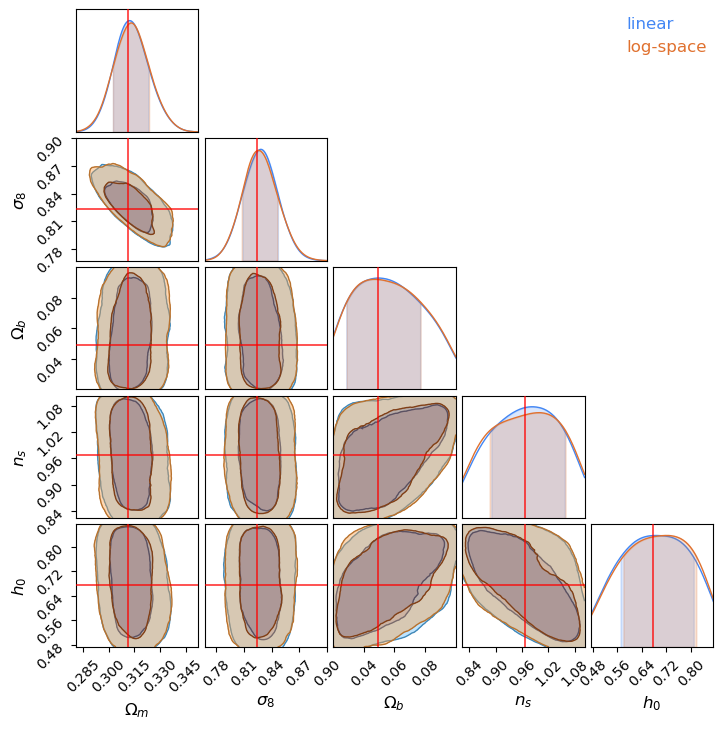

In [5]:
# sigma8 is sampled directly (s8 emulator) — the physically interpretable
# clustering amplitude cluster cosmology constraints are quoted in.
# Overlay both runs to confirm the log transform leaves the posterior unchanged.
cosmo_cols = ['omega_m', 'sigma8', 'omega_b', 'n_s', 'h0']
cosmo_labels = [r'$\Omega_m$', r'$\sigma_8$', r'$\Omega_b$', r'$n_s$', r'$h_0$']

c_cosmo = ChainConsumer()
for name, color in [('linear', '#4286f4'), ('log-space', '#e0712f')]:
    df = chains[name]
    c_cosmo.add_chain(df[cosmo_cols].values, parameters=cosmo_labels,
                      weights=df['weight'].values, name=name)
c_cosmo.configure(plot_hists=True, kde=1.5, colors=['#4286f4', '#e0712f'],
                  summary=True, linewidths=1.0, shade_alpha=0.4)
c_cosmo.configure_truth(color='r', ls='-', lw=1.2, alpha=0.8)

truth_cosmo = [fid[c] for c in cosmo_cols]
fig = c_cosmo.plotter.plot(figsize=1.0, truth=truth_cosmo,
                           filename='./polychord_widePlanck_cosmo.png')

## 2. HOD corner plot (linear vs log-space overlay)

Plotting `log10_M1` (reconstructed) instead of the sampled `log10_ratio`.

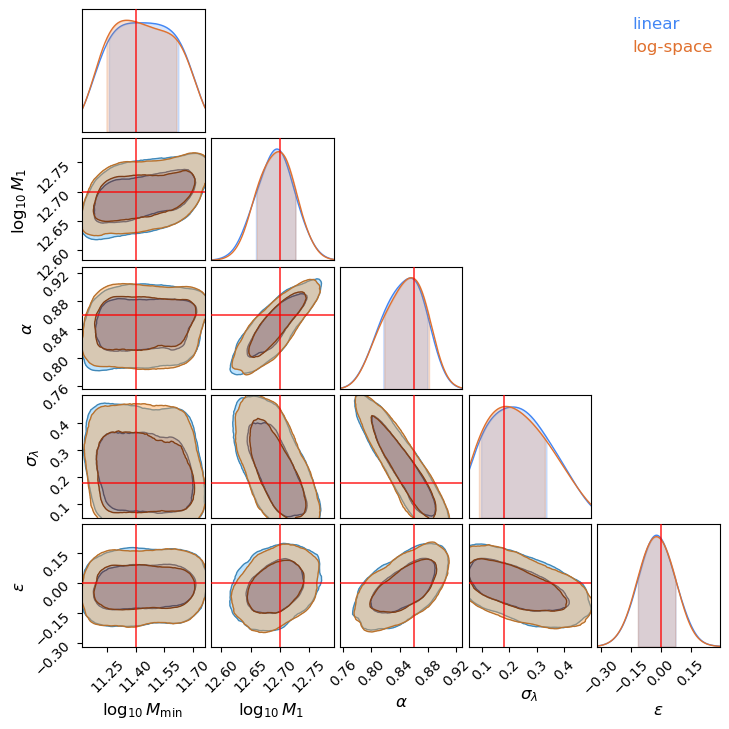

In [6]:
hod_cols = ['log10_mmin', 'log10_m1', 'alpha', 'sigma_lambda', 'epsilon']
hod_labels = [r'$\log_{10}M_{\min}$', r'$\log_{10}M_1$', r'$\alpha$',
              r'$\sigma_\lambda$', r'$\epsilon$']

c_hod = ChainConsumer()
for name, color in [('linear', '#4286f4'), ('log-space', '#e0712f')]:
    df = chains[name]
    c_hod.add_chain(df[hod_cols].values, parameters=hod_labels,
                    weights=df['weight'].values, name=name)
c_hod.configure(plot_hists=True, kde=1.5, colors=['#4286f4', '#e0712f'],
                summary=True, linewidths=1.0, shade_alpha=0.4)
c_hod.configure_truth(color='r', ls='-', lw=1.2, alpha=0.8)

truth_hod = [fid[c] for c in hod_cols]
fig = c_hod.plotter.plot(figsize=1.0, truth=truth_hod,
                         filename='./polychord_widePlanck_HOD.png')

## 3. Closure summary table (linear vs log-space)

Weighted mean / std per param vs fiducial, and the recovery in units of sigma,
for BOTH runs side by side. Identical recovery = the A/B null result.

In [7]:
def closure(df):
    w = df['weight'].values
    out = {}
    for col in cosmo_cols + hod_cols:
        x = df[col].values
        mean = np.average(x, weights=w)
        std = np.sqrt(np.average((x - mean)**2, weights=w))
        out[col] = (mean, std, abs(mean - fid[col]) / std)
    return out

cl = {name: closure(df) for name, df in chains.items()}
rows = []
for col in cosmo_cols + hod_cols:
    lm, ls, lp = cl['linear'][col]
    gm, gs, gp = cl['log-space'][col]
    rows.append((col, fid[col], lm, ls, lp, gm, gs, gp))

summary = pd.DataFrame(rows, columns=[
    'param', 'fiducial',
    'lin_mean', 'lin_std', 'lin_pull',
    'log_mean', 'log_std', 'log_pull'])
summary['max_pull'] = summary[['lin_pull', 'log_pull']].max(axis=1)
summary['within_1sigma'] = summary['max_pull'] < 1.0
summary.round(4)

,param,fiducial,lin_mean,lin_std,lin_pull,log_mean,log_std,log_pull,max_pull,within_1sigma
0,omega_m,0.3110,0.3135,0.0094,0.2611,0.3135,0.0096,0.2576,0.2611,True
1,sigma8,0.8238,0.8278,0.0174,0.2304,0.8277,0.0176,0.2214,0.2304,True
2,omega_b,0.0490,0.0562,0.0216,0.3365,0.0566,0.0217,0.3509,0.3509,True
3,n_s,0.9665,0.9680,0.0740,0.0197,0.9675,0.0763,0.0128,0.0197,True
4,h0,0.6766,0.6838,0.1058,0.0680,0.6880,0.1056,0.1077,0.1077,True
5,log10_mmin,11.4000,11.4426,0.1551,0.2750,11.4385,0.1553,0.2478,0.2750,True
6,log10_m1,12.7000,12.6922,0.0305,0.2551,12.6935,0.0298,0.2193,0.2551,True
7,alpha,0.8600,0.8454,0.0275,0.5326,0.8466,0.0277,0.4823,0.5326,True
8,sigma_lambda,0.1800,0.2348,0.1076,0.5089,0.2313,0.1096,0.4678,0.5089,True
9,epsilon,0.0000,-0.0189,0.0853,0.2212,-0.0207,0.0847,0.2446,0.2446,True


## 4. Trace plots (raw, by stored order)

Note: polychord is a nested sampler, so these are NOT MCMC walker traces -
they are dead points in the order written. Useful as a sanity check that the
likelihood is climbing, not for autocorrelation.

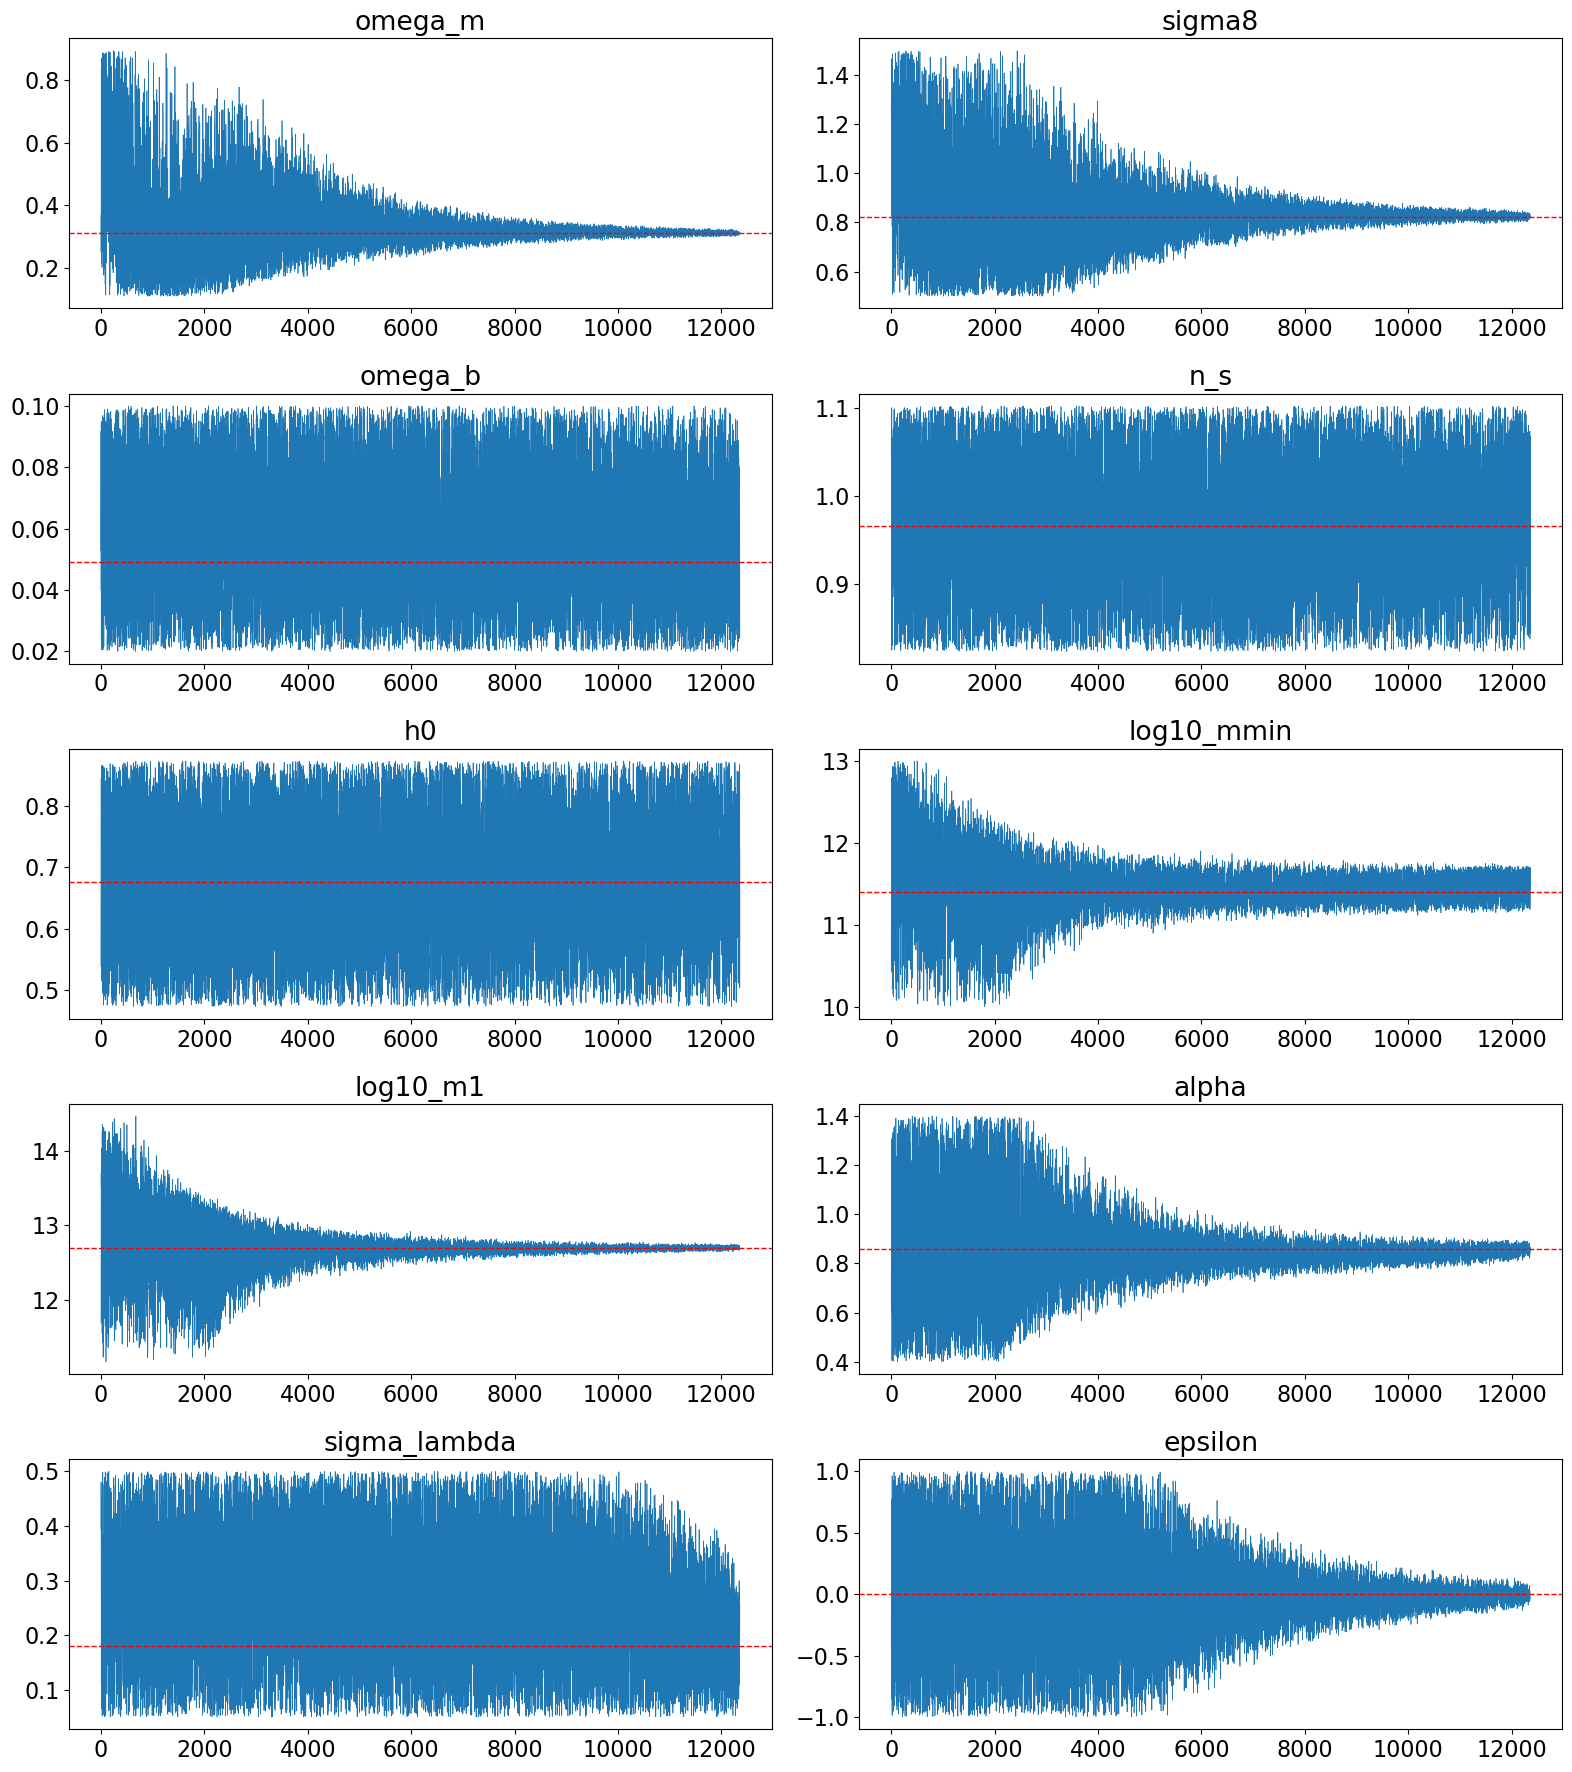

In [8]:
trace_cols = cosmo_cols + hod_cols
fig, axs = plt.subplots(5, 2, figsize=(16, 18))
for ax, col in zip(axs.flat, trace_cols):
    ax.plot(chain[col].values, lw=0.5)
    ax.axhline(fid[col], color='r', ls='--', lw=1)
    ax.set_title(col)
plt.tight_layout()
plt.savefig('./polychord_widePlanck_trace.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Data vector & fit diagnostic — why are the contours broad?

The mock data vector lives in `mock_dv_widePlanck_jkcov.npz`:
- `data_NC` (12) = 4 richness × 3 redshift number counts
- `data_Shear` (120) = 12 bins × **10** radii tangential shear

Error bars are √diag of the covariance (Poisson for NC, Buzzard jackknife for
shear). Plotting data ± error reveals the **signal-to-noise per bin** — i.e.
where the constraining power actually is.

NC    : total SNR = 95.1, per-bin S/N 9.4-49.7
Shear : total SNR = 215.0, per-bin S/N 30.0-139.1, median sigma/data = 6.0%


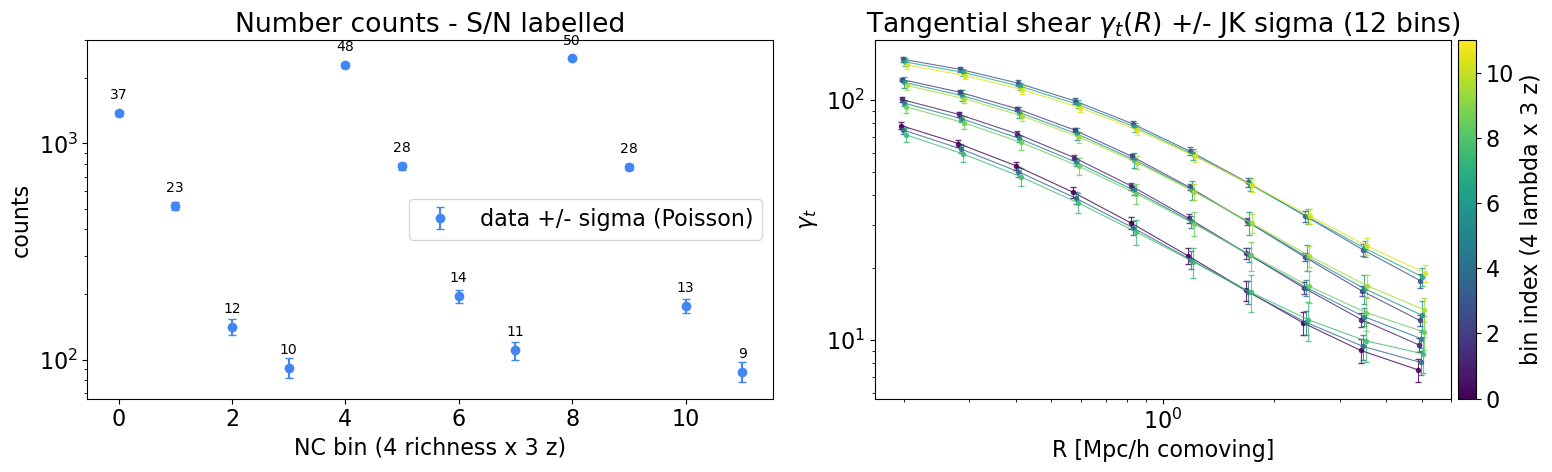

In [9]:
DV = '/pscratch/sd/j/jesteves/github/des-cluster-nersc/data/mock/mock_dv_widePlanck_jkcov.npz'
dv = np.load(DV)
data_NC, data_Shear = dv['data_NC'], dv['data_Shear']
sigma_NC = np.sqrt(np.diag(np.linalg.inv(dv['invcov_NC'])))
sigma_Shear = np.sqrt(np.diag(np.linalg.inv(dv['invcov_Shear'])))

# Active pipeline shear grid: 12 bins x 10 radii = 120 (Shear1hMisSel r_perp
# in mock_mcmc_cp_camb.ini), Mpc/h comoving.
N_R = 10
radii = np.array([0.20000, 0.28599, 0.40896, 0.58480, 0.83625,
                  1.19581, 1.70998, 2.44521, 3.49658, 5.00000])
assert data_Shear.size == 12 * N_R, data_Shear.size

shear_grid = data_Shear.reshape(12, N_R)
sig_grid   = sigma_Shear.reshape(12, N_R)

snr_NC = data_NC / sigma_NC
shear_snr = np.sqrt((shear_grid**2 / sig_grid**2).sum(axis=1))  # per-bin S/N
print(f"NC    : total SNR = {np.sqrt(data_NC @ dv['invcov_NC'] @ data_NC):.1f}, "
      f"per-bin S/N {snr_NC.min():.1f}-{snr_NC.max():.1f}")
print(f"Shear : total SNR = {np.sqrt(data_Shear @ dv['invcov_Shear'] @ data_Shear):.1f}, "
      f"per-bin S/N {shear_snr.min():.1f}-{shear_snr.max():.1f}, "
      f"median sigma/data = {np.median(sig_grid/shear_grid):.1%}")

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(16, 5))

# --- NC: counts with Poisson error bars, log y for the ~30x dynamic range ---
x = np.arange(12)
ax0.errorbar(x, data_NC, yerr=sigma_NC, fmt='o', color='#4286f4',
             capsize=3, label='data +/- sigma (Poisson)')
for xi, s in zip(x, snr_NC):
    ax0.annotate(f'{s:.0f}', (xi, data_NC[xi]), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=10)
ax0.set_yscale('log')
ax0.set_xlabel('NC bin (4 richness x 3 z)'); ax0.set_ylabel('counts')
ax0.set_title('Number counts - S/N labelled'); ax0.legend()

# --- Shear: gamma_t(R) profile per bin WITH error bars (yerr = JK sigma) ---
# 12 bins on a viridis ramp; slight x-jitter so overlapping error bars at the
# same radius stay readable. Error bars (sigma ~0.6-6) are now drawn directly
# on each data point instead of a detached grey envelope.
colors = plt.cm.viridis(np.linspace(0, 0.95, 12))
jit = np.linspace(-0.02, 0.02, 12)  # fractional radius offset, log-friendly
for b in range(12):
    ax1.errorbar(radii * (1 + jit[b]), shear_grid[b], yerr=sig_grid[b],
                 fmt='o-', ms=3, lw=0.8, capsize=2, color=colors[b],
                 alpha=0.8)
sm = plt.cm.ScalarMappable(cmap='viridis',
                           norm=plt.Normalize(vmin=0, vmax=11))
cbar = fig.colorbar(sm, ax=ax1, pad=0.01)
cbar.set_label('bin index (4 lambda x 3 z)')
ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel('R [Mpc/h comoving]'); ax1.set_ylabel(r'$\gamma_t$')
ax1.set_title(r'Tangential shear $\gamma_t(R)$ +/- JK sigma (12 bins)')

plt.tight_layout()
plt.savefig('./polychord_widePlanck_datavector.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Convergence diagnostic — Buzzard run (job 56546840)

PolyChord is a **nested sampler**, not an MCMC walker, so Gelman–Rubin /
autocorrelation don't apply. Convergence here means:

1. the likelihood contour has stopped climbing (panel **a**), and
2. the posterior **weight** profile has risen to a peak and decayed back to ~0
   (panels **b**, **c**) — i.e. the bulk of the posterior mass has been
   collected.

The Buzzard production run **hit the 9 h wall (`TIMEOUT`) before converging**:
`log(Z)` was still *Still Active*, the weight profile peaks at the very last
dead point, and ~99% of the posterior weight sits in the final 5% of samples
(ESS ~ 320). The posterior means below are therefore **preliminary** —
re-submit `fast-cpu/buzzard_polychord.sh` with `polychord.resume=T` to finish.

Early direction (panel **d**): Ω_m running high (~1.4× fiducial), h₀ low
(~0.7×), σ₈ and log₁₀M_min near fiducial — the recovery bias the pre-flight
fit-check predicted (Buzzard has fewer clusters but stronger lensing).

Buzzard: 26212 dead points, ESS ~ 4355, 21% of posterior weight in the last 5% of samples => NOT converged


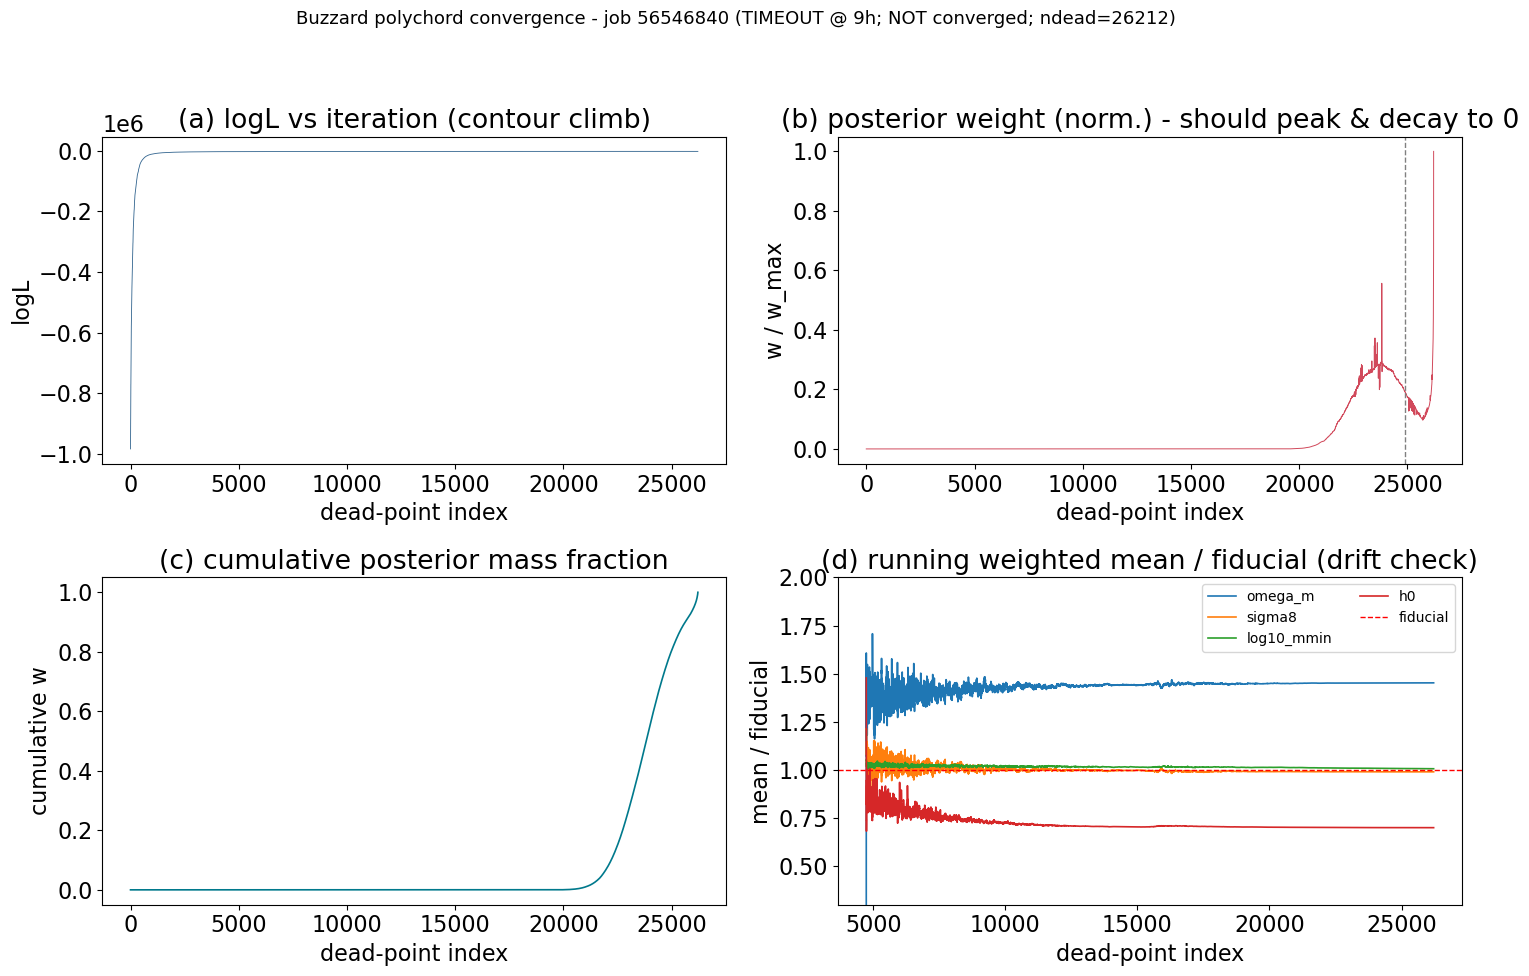

In [10]:
# --- Buzzard run convergence (nested sampling) ---
# PolyChord is not MCMC: convergence = the likelihood contour has stopped
# climbing AND the posterior WEIGHT profile has peaked and decayed to ~0. If
# the run is truncated (wall-time) while weights are still large, the posterior
# bulk has NOT been collected. Buzzard job 56546840 hit the 9h wall (TIMEOUT).
buzz = load_chain('/pscratch/sd/j/jesteves/cluster_lib/chains/mock_mcmc/buzzard/chain.txt')
w, logL = buzz['weight'].values, buzz['like'].values
n = len(buzz); idx = np.arange(n); cw = np.cumsum(w)
ess = w.sum()**2 / (w**2).sum()
tail = w[int(0.95 * n):].sum() / w.sum()   # weight fraction in last 5%
print(f'Buzzard: {n} dead points, ESS ~ {ess:.0f}, '
      f'{tail:.0%} of posterior weight in the last 5% of samples '
      f'=> {"NOT converged" if tail > 0.1 else "converged"}')

key = ['omega_m', 'sigma8', 'log10_mmin', 'h0']
fig, ax = plt.subplots(2, 2, figsize=(15, 10))
ax[0, 0].plot(idx, logL, lw=0.6, color='#30638e')
ax[0, 0].set(title='(a) logL vs iteration (contour climb)',
             xlabel='dead-point index', ylabel='logL')
ax[0, 1].plot(idx, w / w.max(), lw=0.7, color='#d1495b')
ax[0, 1].axvline(0.95 * n, color='0.5', ls='--', lw=1)
ax[0, 1].set(title='(b) posterior weight (norm.) - should peak & decay to 0',
             xlabel='dead-point index', ylabel='w / w_max')
ax[1, 0].plot(idx, cw / cw[-1], lw=1.2, color='#00798c')
ax[1, 0].set(title='(c) cumulative posterior mass fraction',
             xlabel='dead-point index', ylabel='cumulative w')
for c in key:
    rm = np.cumsum(w * buzz[c].values) / np.where(cw > 0, cw, np.nan)
    ax[1, 1].plot(idx, rm / fid[c], lw=1.2, label=c)
ax[1, 1].axhline(1.0, color='r', ls='--', lw=1, label='fiducial')
ax[1, 1].set(title='(d) running weighted mean / fiducial (drift check)',
             xlabel='dead-point index', ylabel='mean / fiducial', ylim=(0.3, 2.0))
ax[1, 1].legend(fontsize=10, ncol=2)
fig.suptitle(f'Buzzard polychord convergence - job 56546840 '
             f'(TIMEOUT @ 9h; NOT converged; ndead={n})', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('./polychord_buzzard_convergence.png', dpi=140, bbox_inches='tight')
plt.show()

## 7. Buzzard (real sim) runs — h-unit fix and the covariance issue

Pipeline applied to the **Buzzard simulation** data vector
(`xtang126/mock_cluster_buzzard`) instead of the self-closure theory. Two runs:
- **unfixed** (`buzzard/`, job 56546840): mock DeltaSigma harvested in *physical*
  M_sun/pc^2, mismatched to the model's little-h units (h*M_sun/pc^2) by one power of h.
- **h-fixed** (`buzzard_hfix/`, job 56669090): stopgap DeltaSigma x h_buzz(0.7).

PolyChord output is weighted -> use ChainConsumer with `weights=` (the `.stats`
"Sigma" column is NOT the marginalized width). **Open issue (7.3-7.4):** the fit
is poor (chi2 ~ 20/dof) and the posterior rails at prior bounds because the JK
covariance is unrealistically tight (mock intrinsic scatter, no shape noise ~4%)
while the model has a ~11% coherent radial-tilt misspecification.

In [11]:
# Load the two Buzzard chains (same weighted load_chain as the closure runs)
CH = '/pscratch/sd/j/jesteves/cluster_lib/chains/mock_mcmc'
buzz = {'unfixed': load_chain(f'{CH}/buzzard/chain.txt'),
        'h-fixed': load_chain(f'{CH}/buzzard_hfix/chain.txt')}
bcolors = ['#c94f4f', '#3d7dc9']
for name, df in buzz.items():
    df['log10_m1'] = df['log10_mmin'] + df['log10_ratio']
    ess = df['weight'].sum()**2 / (df['weight']**2).sum()
    print(f'{name:8s}: {len(df)} weighted samples, ESS ~ {ess:.0f}')

unfixed : 26212 weighted samples, ESS ~ 4355
h-fixed : 21203 weighted samples, ESS ~ 4226


### 7.1 Cosmology corner — unfixed vs h-fixed (dashed = fiducial truth)

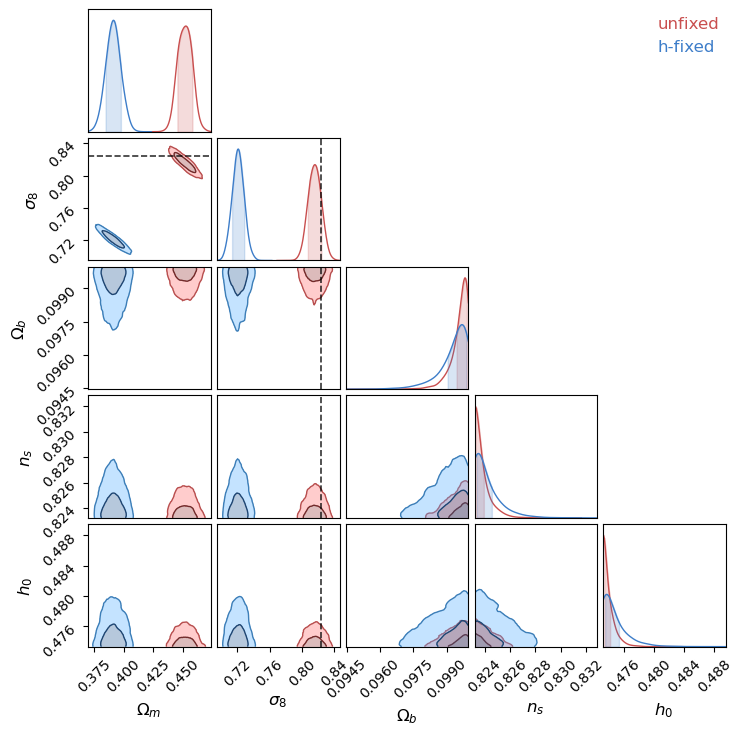

In [12]:
c_bz = ChainConsumer()
for name, df in buzz.items():
    c_bz.add_chain(df[cosmo_cols].values, parameters=cosmo_labels,
                   weights=df['weight'].values, name=name)
c_bz.configure(plot_hists=True, kde=1.5, colors=bcolors, summary=True,
               linewidths=1.0, shade_alpha=0.35)
c_bz.configure_truth(color='k', ls='--', lw=1.2, alpha=0.8)
fig = c_bz.plotter.plot(figsize=1.0, truth=[fid[c] for c in cosmo_cols],
                        filename='./polychord_buzzard_cosmo.png')

### 7.2 HOD corner

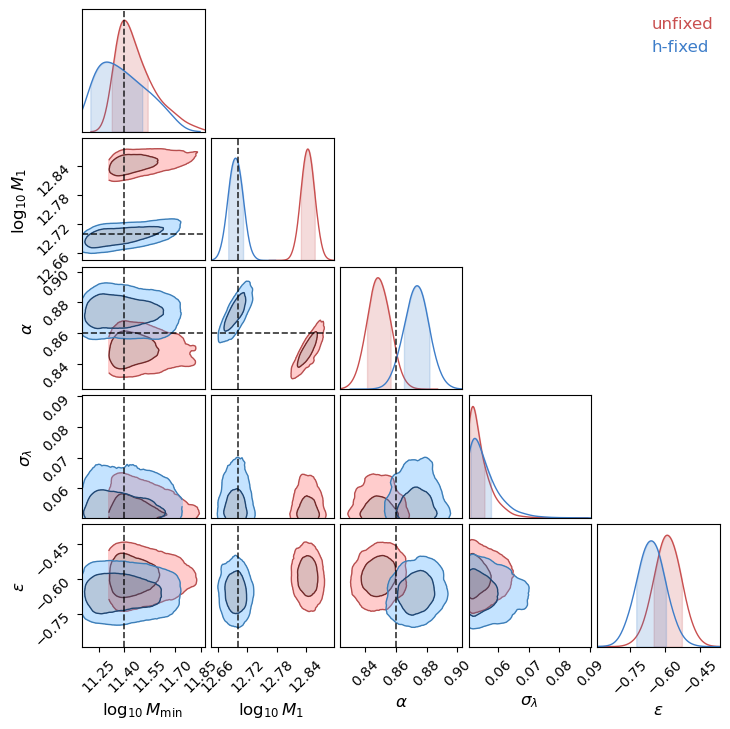

In [13]:
c_bh = ChainConsumer()
for name, df in buzz.items():
    c_bh.add_chain(df[hod_cols].values, parameters=hod_labels,
                   weights=df['weight'].values, name=name)
c_bh.configure(plot_hists=True, kde=1.5, colors=bcolors, summary=True,
               linewidths=1.0, shade_alpha=0.35)
c_bh.configure_truth(color='k', ls='--', lw=1.2, alpha=0.8)
fig = c_bh.plotter.plot(figsize=1.0, truth=[fid[c] for c in hod_cols],
                        filename='./polychord_buzzard_HOD.png')

### 7.3 Data vs best-fit (h-fixed) + chi2

Theory at the max-likelihood point of the h-fixed chain vs the Buzzard data.
The shear tracks well at small-mid R but the data drops below at large R.

best-fit chi2: NC=426/12  Shear=2163/120  total=2589/132 = 19.6/dof


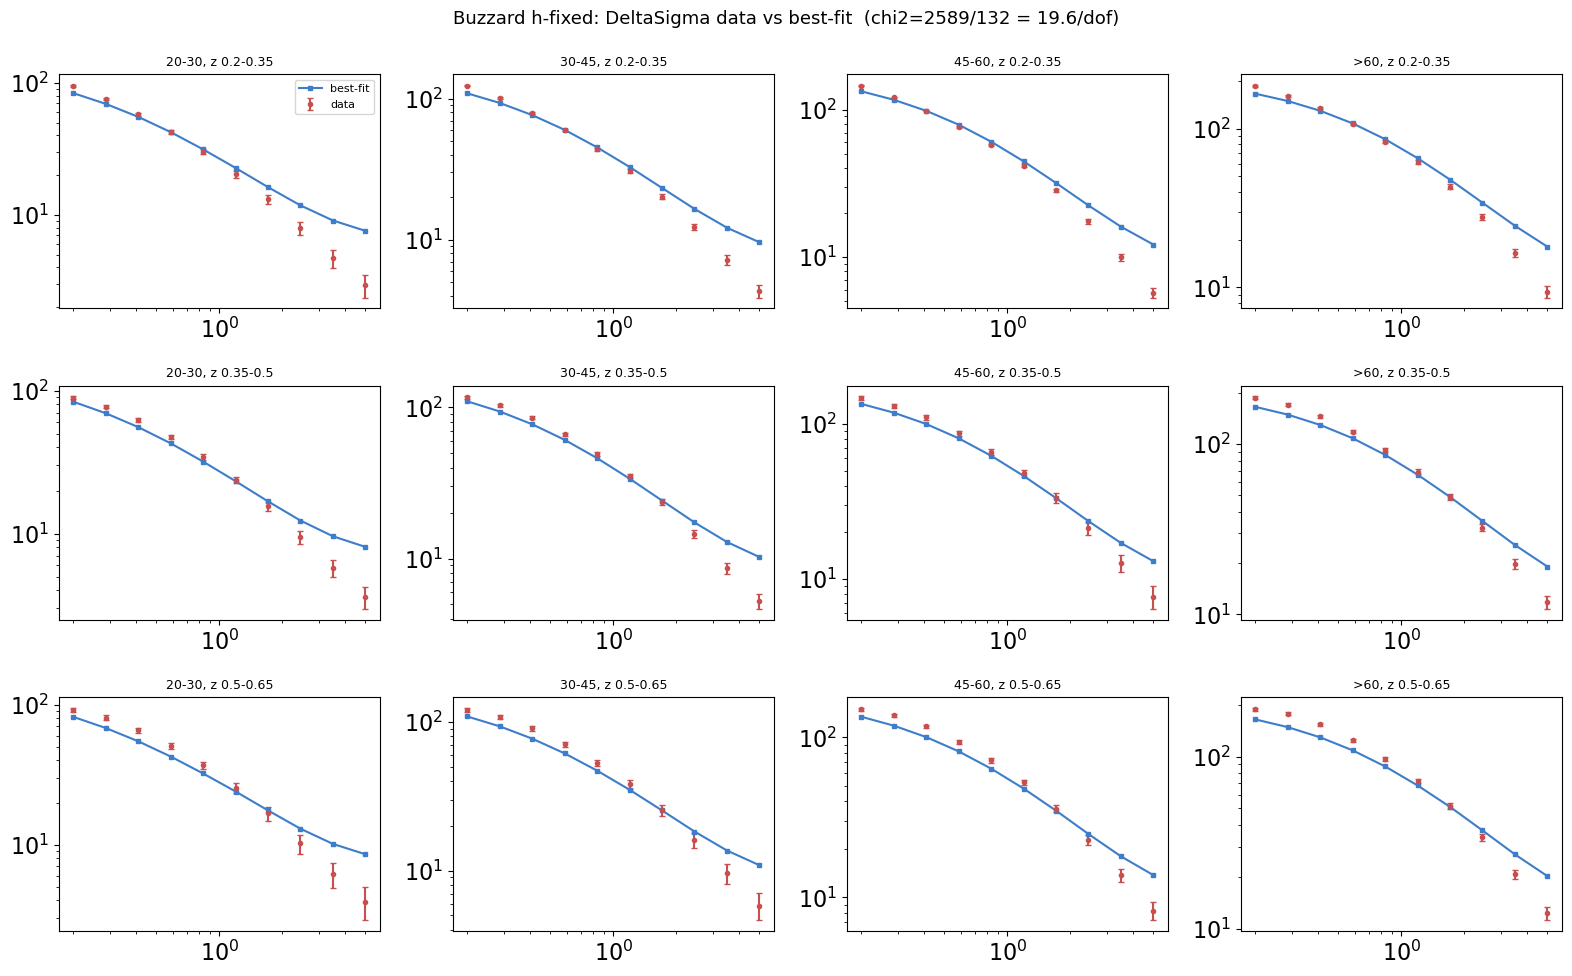

In [14]:
DVH = '/pscratch/sd/j/jesteves/github/des-cluster-nersc/data/mock/dv_buzzard_jkcov_hfix.npz'
BF = f'{CH}/buzzard_hfix/bestfit_test'
_col = lambda s: np.loadtxt(f'{BF}/{s}/vals.txt', comments='#').ravel()
dvh = np.load(DVH)
dNC, dSH = dvh['data_NC'].astype(float), dvh['data_Shear'].astype(float)
icNC, icSH = dvh['invcov_NC'].astype(float), dvh['invcov_Shear'].astype(float)
sNC = np.sqrt(np.diag(np.linalg.inv(icNC))); sSH = np.sqrt(np.diag(np.linalg.inv(icSH)))
tNC = _col('numcountssel'); tSH = _col('shear1hmissel')/np.repeat(tNC, N_R) + _col('shear_prj')
chi2NC = float((dNC-tNC)@icNC@(dNC-tNC)); chi2SH = float((dSH-tSH)@icSH@(dSH-tSH))
print(f'best-fit chi2: NC={chi2NC:.0f}/12  Shear={chi2SH:.0f}/120  '
      f'total={chi2NC+chi2SH:.0f}/132 = {(chi2NC+chi2SH)/132:.1f}/dof')

LBD=['20-30','30-45','45-60','>60']; ZED=['0.2-0.35','0.35-0.5','0.5-0.65']
dg,tg,sg = dSH.reshape(12,N_R), tSH.reshape(12,N_R), sSH.reshape(12,N_R)
fig,axs = plt.subplots(3,4,figsize=(16,10))
for b,ax in enumerate(axs.flat):
    ax.errorbar(radii, dg[b], yerr=sg[b], fmt='o', ms=3, color='#c94f4f', capsize=2, label='data')
    ax.plot(radii, tg[b], 's-', ms=3, color='#3d7dc9', label='best-fit')
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_title(f'{LBD[b%4]}, z {ZED[b//4]}', fontsize=9)
    if b==0: ax.legend(fontsize=8)
fig.suptitle(f'Buzzard h-fixed: DeltaSigma data vs best-fit  '
             f'(chi2={chi2NC+chi2SH:.0f}/132 = {(chi2NC+chi2SH)/132:.1f}/dof)', fontsize=13)
plt.tight_layout(); plt.savefig('./buzzard_hfix_data_vs_bestfit.png', dpi=140, bbox_inches='tight'); plt.show()

### 7.4 chi2 breakdown + the covariance problem

The chi2 is a U-shape in radius (misfit at both ends = the radial tilt). The
covariance panel is the crux: the pipeline's reused (closure-mock) errors and
the Buzzard mock's own JK errors are BOTH ~4% (no shape noise), far below the
~11% coherent model residual -> the fit is model-error-dominated, so the
posterior rails and its formal errors are meaningless.

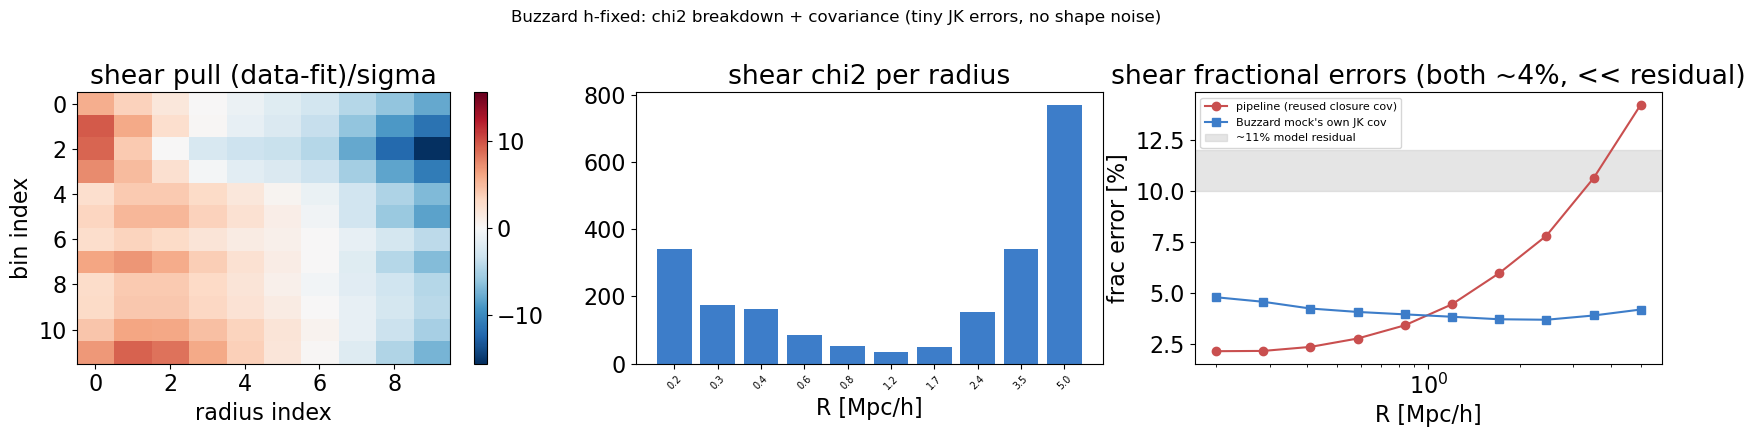

In [15]:
r = dSH - tSH
contribR = (r*(icSH@r)).reshape(12,N_R).sum(0)      # shear chi2 per radius
pull = (r/sSH).reshape(12,N_R)
frac_pipe = (sSH/np.abs(dSH)).reshape(12,N_R).mean(0)
mock = np.load('/pscratch/sd/j/jesteves/github/mock_cluster_buzzard/output/MockDataVector.npz', allow_pickle=True)
gm = mock['gamma_t_mock_obs_C1'].astype(float); cm = mock['shear_data_vector_cov'].astype(float)
frac_mock_all = np.median((np.sqrt(np.diagonal(cm,axis1=2,axis2=3))/np.abs(gm)).reshape(12,11),0)
mock_r = np.geomspace(0.166,15.8,11); frac_mock = np.interp(np.log(radii), np.log(mock_r), frac_mock_all)

fig,ax = plt.subplots(1,3,figsize=(17,4.5))
im=ax[0].imshow(pull, aspect='auto', cmap='RdBu_r', vmin=-np.abs(pull).max(), vmax=np.abs(pull).max())
ax[0].set_title('shear pull (data-fit)/sigma'); ax[0].set_xlabel('radius index'); ax[0].set_ylabel('bin index'); fig.colorbar(im,ax=ax[0])
ax[1].bar(range(N_R), contribR, color='#3d7dc9')
ax[1].set_xticks(range(N_R)); ax[1].set_xticklabels([f'{x:.1f}' for x in radii], rotation=45, fontsize=7)
ax[1].set_title('shear chi2 per radius'); ax[1].set_xlabel('R [Mpc/h]')
ax[2].plot(radii, frac_pipe*100, 'o-', color='#c94f4f', label='pipeline (reused closure cov)')
ax[2].plot(radii, frac_mock*100, 's-', color='#3d7dc9', label="Buzzard mock's own JK cov")
ax[2].axhspan(10,12, color='0.8', alpha=0.5, label='~11% model residual')
ax[2].set_xscale('log'); ax[2].set_xlabel('R [Mpc/h]'); ax[2].set_ylabel('frac error [%]')
ax[2].set_title('shear fractional errors (both ~4%, << residual)'); ax[2].legend(fontsize=8)
fig.suptitle('Buzzard h-fixed: chi2 breakdown + covariance (tiny JK errors, no shape noise)', fontsize=12)
plt.tight_layout(); plt.savefig('./buzzard_hfix_chi2.png', dpi=140, bbox_inches='tight'); plt.show()